<a href="https://colab.research.google.com/github/seeuni0320/AI-ML/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 인공지능과 기계학습 - Week4-5: 분류
## MNIST 데이터셋을 이용한 분류기 실습

---
**내용 구성:**
- 3.1 MNIST 데이터셋
- 3.2 이진 분류기 훈련
- 3.3 성능 측정 (오차 행렬, 정밀도/재현율, ROC)
- 3.4 다중 분류
- 3.5 오류 분석
- 3.6 다중 레이블 분류
- 3.7 다중 출력 분류
- **연습문제 1: KNN으로 97% 정확도 달성하기**
- **연습문제 2: 데이터 증식(Data Augmentation) 구현하기**

## ⚙️ 라이브러리 설치 및 임포트

In [ ]:
# 한글 폰트 설정 (Colab)
!apt-get install -y fonts-nanum -qq
!fc-cache -fv

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 한글 폰트 설정 완료!")

In [1]:
# Google Colab 환경에서 필요한 라이브러리 설치
!pip install scikit-learn matplotlib seaborn scipy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.ndimage import shift

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score, cross_val_predict,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, roc_auc_score,
    classification_report
)
from sklearn.base import clone

import warnings
warnings.filterwarnings('ignore')

# 재현성을 위한 랜덤 시드 설정
np.random.seed(42)

print("✅ 모든 라이브러리 임포트 완료!")

✅ 모든 라이브러리 임포트 완료!


---
## 3.1 MNIST 데이터셋

In [3]:
# MNIST 데이터셋 내려받기
print("MNIST 데이터셋 로딩 중... (시간이 걸릴 수 있습니다)")
mnist = fetch_openml('mnist_784', as_frame=False)

X, y = mnist.data, mnist.target
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y 샘플: {y[:5]}")

MNIST 데이터셋 로딩 중... (시간이 걸릴 수 있습니다)
X shape: (70000, 784)
y shape: (70000,)
y 샘플: ['5' '0' '4' '1' '9']


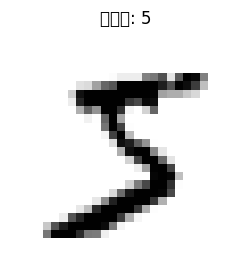

y[0] = '5'


In [4]:
# 이미지 시각화 함수 정의
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

# 첫 번째 이미지 확인 (그림 3-1)
some_digit = X[0]
plt.figure(figsize=(3, 3))
plot_digit(some_digit)
plt.title(f"레이블: {y[0]}")
plt.show()
print(f"y[0] = '{y[0]}'")

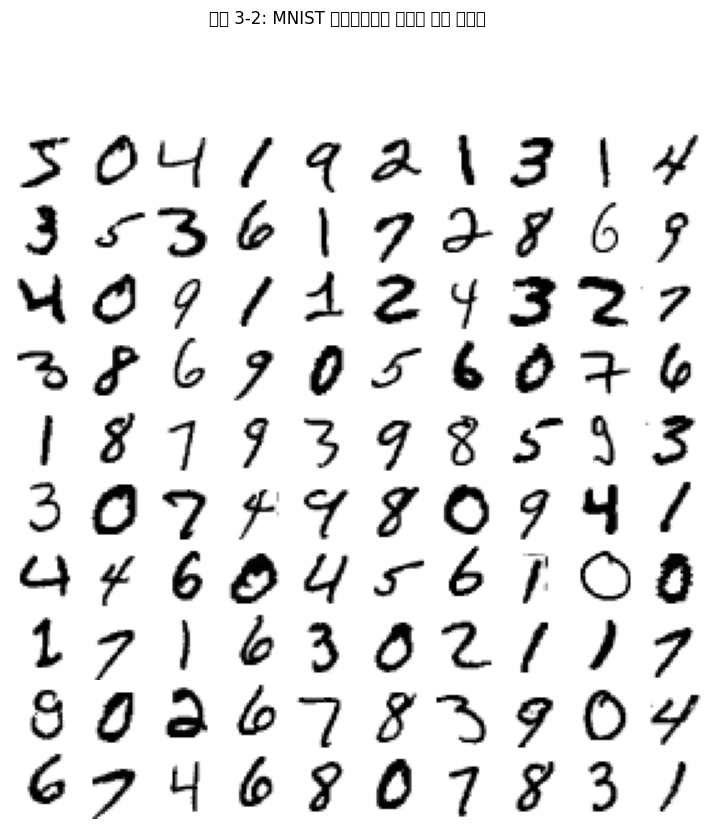

In [5]:
# MNIST 이미지 샘플 100개 시각화 (그림 3-2)
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.suptitle("그림 3-2: MNIST 데이터셋에서 추출한 숫자 이미지", y=1.01)
plt.show()

In [6]:
# 훈련 세트 / 테스트 세트 분리
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
print(f"훈련 세트: {X_train.shape}")
print(f"테스트 세트: {X_test.shape}")

훈련 세트: (60000, 784)
테스트 세트: (10000, 784)


---
## 3.2 이진 분류기 훈련

'5-감지기': '5' vs '5 아님' 두 클래스를 구분하는 이진 분류기(binary classifier)

In [7]:
# 타깃 벡터 생성 (5는 True, 나머지는 False)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

print(f"훈련 세트에서 숫자 5의 개수: {y_train_5.sum()}")
print(f"훈련 세트 전체 개수: {len(y_train_5)}")
print(f"비율: {y_train_5.mean():.2%}")

훈련 세트에서 숫자 5의 개수: 5421
훈련 세트 전체 개수: 60000
비율: 9.04%


In [8]:
# SGDClassifier 훈련 (확률적 경사 하강법)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# 예측
result = sgd_clf.predict([some_digit])
print(f"some_digit(숫자 5) 예측 결과: {result}")
print(f"실제 레이블: {y[0]}")

some_digit(숫자 5) 예측 결과: [ True]
실제 레이블: 5


---
## 3.3 성능 측정

### 3.3.1 교차 검증을 사용한 정확도 측정

In [9]:
# k-폴드 교차 검증 (k=3)
print("SGDClassifier 교차 검증 점수 계산 중...")
cv_scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(f"SGDClassifier 교차 검증 정확도: {cv_scores}")
print(f"평균: {cv_scores.mean():.4f}")

SGDClassifier 교차 검증 점수 계산 중...
SGDClassifier 교차 검증 정확도: [0.95035 0.96035 0.9604 ]
평균: 0.9570


In [10]:
# 더미 분류기 비교 (모든 것을 '5 아님'으로 분류)
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(f"더미 분류기가 True로 예측한 것: {any(dummy_clf.predict(X_train))}")

dummy_scores = cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(f"더미 분류기 교차 검증 정확도: {dummy_scores}")
print("=> 이처럼 불균형 데이터셋에서 정확도는 좋은 지표가 아님!")

더미 분류기가 True로 예측한 것: False
더미 분류기 교차 검증 정확도: [0.90965 0.90965 0.90965]
=> 이처럼 불균형 데이터셋에서 정확도는 좋은 지표가 아님!


### 3.3.2 오차 행렬 (Confusion Matrix)

In [11]:
# 교차 검증으로 예측값 생성
print("교차 검증 예측 생성 중...")
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

# 오차 행렬 생성
cm = confusion_matrix(y_train_5, y_train_pred)
print("오차 행렬:")
print(cm)
print(f"\n- 진짜 음성(TN): {cm[0,0]}  # '5 아님'을 '5 아님'으로 올바르게 분류")
print(f"- 거짓 양성(FP): {cm[0,1]}  # '5 아님'을 '5'로 잘못 분류 (1종 오류)")
print(f"- 거짓 음성(FN): {cm[1,0]}  # '5'를 '5 아님'으로 잘못 분류 (2종 오류)")
print(f"- 진짜 양성(TP): {cm[1,1]}  # '5'를 '5'로 올바르게 분류")

교차 검증 예측 생성 중...
오차 행렬:
[[53892   687]
 [ 1891  3530]]

- 진짜 음성(TN): 53892  # '5 아님'을 '5 아님'으로 올바르게 분류
- 거짓 양성(FP): 687  # '5 아님'을 '5'로 잘못 분류 (1종 오류)
- 거짓 음성(FN): 1891  # '5'를 '5 아님'으로 잘못 분류 (2종 오류)
- 진짜 양성(TP): 3530  # '5'를 '5'로 올바르게 분류


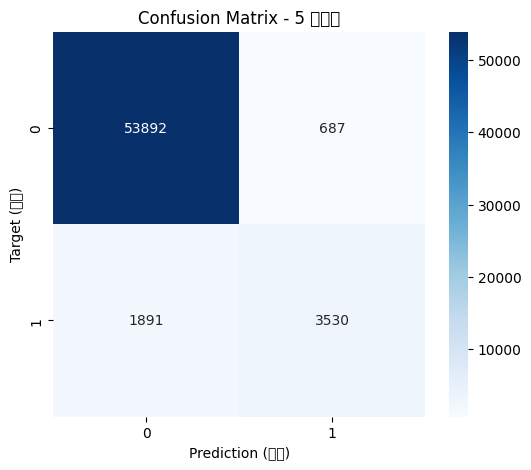

In [12]:
# 오차 행렬 시각화 (seaborn 히트맵)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('Target (실제)')
plt.xlabel('Prediction (예측)')
plt.title('Confusion Matrix - 5 감지기')
plt.show()

### 3.3.3 정밀도와 재현율

$$정밀도 = \frac{TP}{TP + FP}$$

$$재현율 = \frac{TP}{TP + FN}$$

$$F_1 = \frac{2}{\frac{1}{정밀도} + \frac{1}{재현율}} = 2 \times \frac{정밀도 \times 재현율}{정밀도 + 재현율}$$

In [13]:
# 정밀도, 재현율, F1 점수 계산
precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)
f1 = f1_score(y_train_5, y_train_pred)

print(f"정밀도(Precision): {precision:.4f}")
print(f"재현율(Recall):    {recall:.4f}")
print(f"F1 점수:           {f1:.4f}")

# classification_report
print("\n=== Classification Report ===")
report = classification_report(y_train_5, y_train_pred)
print(report)

정밀도(Precision): 0.8371
재현율(Recall):    0.6512
F1 점수:           0.7325

=== Classification Report ===
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



### 3.3.4 정밀도/재현율 트레이드오프

In [14]:
# 결정 함수 점수 확인
y_scores = sgd_clf.decision_function([some_digit])
print(f"some_digit의 결정 점수: {y_scores}")

# 임곗값 0 (기본)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(f"임곗값 0 예측: {y_some_digit_pred}")

# 임곗값 3000 (높임)
threshold_high = 3000
y_some_digit_pred_high = (y_scores > threshold_high)
print(f"임곗값 3000 예측: {y_some_digit_pred_high}  (재현율 낮아짐)")

some_digit의 결정 점수: [2164.22030239]
임곗값 0 예측: [ True]
임곗값 3000 예측: [False]  (재현율 낮아짐)


결정 점수 교차 검증 중...


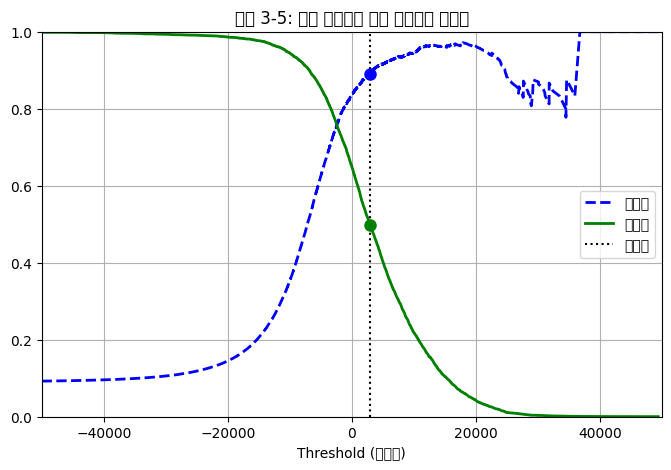

In [15]:
# 모든 샘플에 대한 결정 점수 계산
print("결정 점수 교차 검증 중...")
y_scores_train = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                                   method="decision_function")

# 정밀도-재현율 곡선
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores_train)

# 임곗값 선택 (예: 3000)
threshold_val = 3000
idx = (thresholds >= threshold_val).argmax()

# 그림 3-5: 임곗값에 따른 정밀도/재현율
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="정밀도", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="재현율", linewidth=2)
plt.vlines(threshold_val, 0, 1.0, "k", "dotted", label="임곗값")
plt.plot(thresholds[idx], precisions[idx], "bo", markersize=8)
plt.plot(thresholds[idx], recalls[idx], "go", markersize=8)
plt.axis([-50000, 50000, 0, 1])
plt.grid(True)
plt.xlabel("Threshold (임곗값)")
plt.legend(loc="center right")
plt.title("그림 3-5: 결정 임곗값에 대한 정밀도와 재현율")
plt.show()

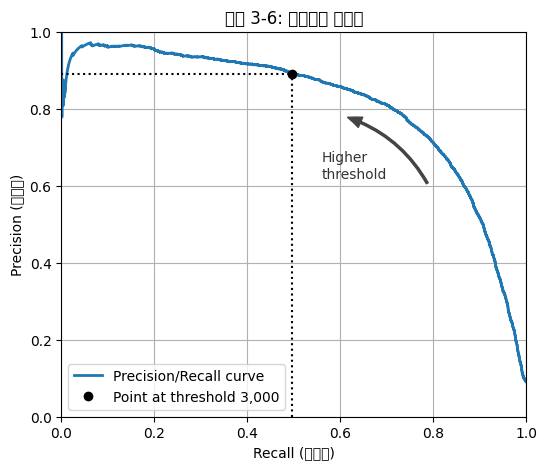

In [16]:
# 그림 3-6: 정밀도-재현율 곡선
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall (재현율)")
plt.ylabel("Precision (정밀도)")
plt.axis([0, 1, 0, 1])
plt.grid(True)
plt.legend(loc="lower left")
plt.title("그림 3-6: 정밀도와 재현율")
plt.show()

In [17]:
# 정밀도 90% 이상이 되는 최저 임곗값 찾기
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(f"정밀도 90% 이상이 되는 임곗값: {threshold_for_90_precision:.4f}")

# 해당 임곗값으로 예측 생성
y_train_pred_90 = (y_scores_train >= threshold_for_90_precision)

p90 = precision_score(y_train_5, y_train_pred_90)
r90 = recall_score(y_train_5, y_train_pred_90)
print(f"정밀도: {p90:.4f}")
print(f"재현율: {r90:.4f}")

정밀도 90% 이상이 되는 임곗값: 3370.0195
정밀도: 0.9000
재현율: 0.4800


### 3.3.5 ROC 곡선

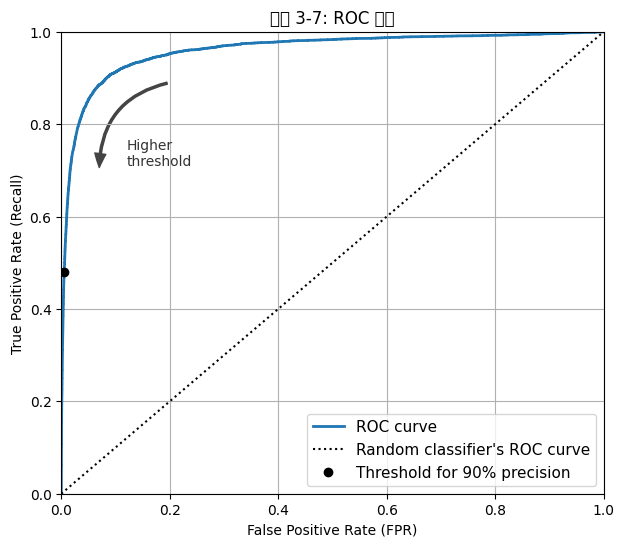

ROC AUC 점수: 0.9605


In [18]:
# ROC 곡선 계산
fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores_train)

# 90% 정밀도 임곗값에서의 TPR/FPR
idx_for_threshold_at_90 = (thresholds_roc <= threshold_for_90_precision).argmax()
tpr_90 = tpr[idx_for_threshold_at_90]
fpr_90 = fpr[idx_for_threshold_at_90]

# 그림 3-7: ROC 곡선
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=11)
plt.title("그림 3-7: ROC 곡선")
plt.show()

# ROC AUC 점수
roc_auc = roc_auc_score(y_train_5, y_scores_train)
print(f"ROC AUC 점수: {roc_auc:.4f}")

RandomForestClassifier 훈련 중...
처음 두 샘플의 클래스 확률:
[[0.11 0.89]
 [0.99 0.01]]


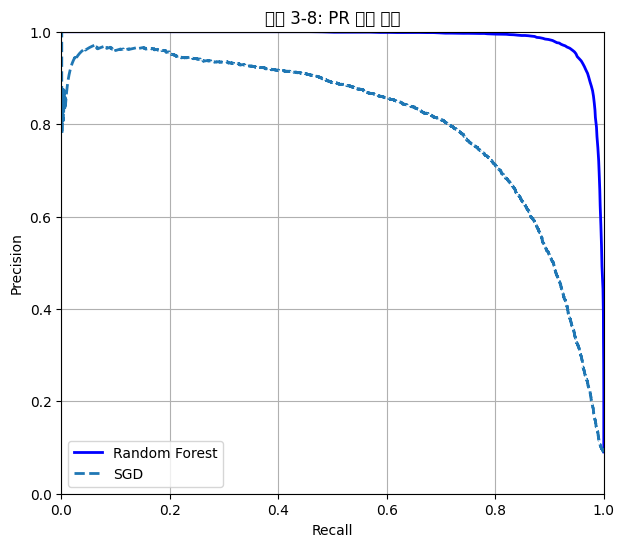

RandomForest F1 점수: 0.9275
RandomForest ROC AUC: 0.9983
SGD F1 점수: 0.7325
SGD ROC AUC: 0.9605


In [19]:
# RandomForest vs SGD 비교
print("RandomForestClassifier 훈련 중...")
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

print(f"처음 두 샘플의 클래스 확률:\n{y_probas_forest[:2]}")

# PR 곡선 비교
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

plt.figure(figsize=(7, 6))
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid(True)
plt.legend(loc="lower left")
plt.title("그림 3-8: PR 곡선 비교")
plt.show()

# F1, AUC 비교
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_forest = f1_score(y_train_5, y_train_pred_forest)
auc_forest = roc_auc_score(y_train_5, y_scores_forest)
print(f"RandomForest F1 점수: {f1_forest:.4f}")
print(f"RandomForest ROC AUC: {auc_forest:.4f}")
print(f"SGD F1 점수: {f1:.4f}")
print(f"SGD ROC AUC: {roc_auc:.4f}")

---
## 3.4 다중 분류

In [ ]:
# SGDClassifier로 다중 분류 (OvR 자동 적용)
sgd_clf_multi = SGDClassifier(random_state=42)
sgd_clf_multi.fit(X_train, y_train)
pred = sgd_clf_multi.predict([some_digit])
print(f"예측 결과: {pred}")

# 결정 함수 점수 (클래스별)
scores = sgd_clf_multi.decision_function([some_digit])
print(f"\n결정 점수: {scores.round(2)}")
print(f"클래스 목록: {sgd_clf_multi.classes_}")

class_id = scores.argmax()
print(f"가장 높은 점수의 클래스 ID: {class_id}")
print(f"예측 클래스: {sgd_clf_multi.classes_[class_id]}")

In [ ]:
# 교차 검증 정확도 평가
print("다중 분류 교차 검증 중...")
cv_scores_multi = cross_val_score(sgd_clf_multi, X_train, y_train, cv=3, scoring="accuracy")
print(f"교차 검증 정확도: {cv_scores_multi}")
print(f"평균: {cv_scores_multi.mean():.4f}")

# 스케일 조정 후 성능 향상
print("\n스케일 조정 후 평가 중...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cv_scores_scaled = cross_val_score(sgd_clf_multi, X_train_scaled, y_train, cv=3, scoring="accuracy")
print(f"스케일 조정 후 정확도: {cv_scores_scaled}")
print(f"평균: {cv_scores_scaled.mean():.4f}")

---
## 3.5 오류 분석

In [ ]:
# 다중 분류 오차 행렬
print("다중 분류 교차 검증 예측 생성 중...")
y_train_pred_multi = cross_val_predict(sgd_clf_multi, X_train_scaled, y_train, cv=3)

# 오차 행렬 시각화 (그림 3-9)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
plt.rc('font', size=9)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_multi, ax=axs[0])
axs[0].set_title("Confusion matrix")

plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_multi, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
plt.suptitle("그림 3-9: 오차 행렬", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 오류만 강조 (그림 3-10)
sample_weight = (y_train_pred_multi != y_train)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
plt.rc('font', size=10)

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred_multi, ax=axs[0],
    sample_weight=sample_weight, normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred_multi, ax=axs[1],
    sample_weight=sample_weight, normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")

plt.suptitle("그림 3-10: 오류 분석", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 그림 3-11: 오차 행렬 스타일로 그린 3과 5의 샘플
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred_multi == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred_multi == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred_multi == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred_multi == cl_b)]

size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                         (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y_pos = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y_pos, y_pos + 1))

plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

---
## 3.6 다중 레이블 분류

In [ ]:
# 다중 레이블 타깃 생성
# - 레이블1: 숫자가 7 이상인가? (Large)
# - 레이블2: 홀수인가? (Odd)
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

print(f"y_multilabel shape: {y_multilabel.shape}")
print(f"처음 5개 샘플: {y_multilabel[:5]}")
print(f"(large ≥7, odd)")

# KNeighborsClassifier 훈련
print("\nKNeighborsClassifier 훈련 중...")
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# 예측 (some_digit은 숫자 5: large=False, odd=True)
result = knn_clf.predict([some_digit])
print(f"\nsome_digit(5) 예측: {result}")
print("  => [False(5<7), True(5는 홀수)]")

In [ ]:
# 다중 레이블 분류기 평가
print("다중 레이블 교차 검증 중 (시간이 걸릴 수 있습니다)...")
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

f1_macro = f1_score(y_multilabel, y_train_knn_pred, average="macro")
f1_weighted = f1_score(y_multilabel, y_train_knn_pred, average="weighted")
print(f"F1 점수 (macro):    {f1_macro:.4f}")
print(f"F1 점수 (weighted): {f1_weighted:.4f}")

---
## 3.7 다중 출력 분류 (잡음 제거)

In [ ]:
# 잡음 추가
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

# 잡음이 섞인 이미지 vs 원본 비교 (그림 3-12)
plt.figure(figsize=(5, 3))
plt.subplot(121)
plt.title("잡음 이미지")
plot_digit(X_test_mod[0])
plt.subplot(122)
plt.title("원본 이미지")
plot_digit(y_test_mod[0])
plt.suptitle("그림 3-12")
plt.show()

# KNN으로 잡음 제거 학습
print("잡음 제거 모델 훈련 중...")
knn_clf_denoise = KNeighborsClassifier()
knn_clf_denoise.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf_denoise.predict([X_test_mod[0]])

plt.figure(figsize=(3, 3))
plot_digit(clean_digit)
plt.title("그림 3-13: 깨끗하게 정리된 이미지")
plt.show()

---
# 📝 연습문제

## 연습문제 1: MNIST 테스트 세트에서 97% 정확도 달성하기

> 힌트: `KNeighborsClassifier`가 이 작업에 잘 맞습니다.  
> `weights`와 `n_neighbors` 하이퍼파라미터로 그리드 탐색을 시도해보세요.

In [ ]:
# ① Baseline 성능 확인하기
print("=" * 50)
print("[연습문제 1] Baseline KNN 성능 확인")
print("=" * 50)

print("KNeighborsClassifier 기본 모델 훈련 중...")
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_train, y_train)

baseline_accuracy = knn_baseline.score(X_test, y_test)
print(f"Baseline 정확도: {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")

In [ ]:
# ② GridSearchCV로 최적 하이퍼파라미터 탐색
print("=" * 50)
print("[연습문제 1] GridSearchCV 하이퍼파라미터 탐색")
print("처음 10,000개 이미지로 빠르게 탐색합니다...")
print("=" * 50)

param_grid = [{
    'weights': ["uniform", "distance"],
    'n_neighbors': [3, 4, 5, 6]
}]

knn_clf_gs = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf_gs, param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train[:10_000], y_train[:10_000])

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"교차 검증 최고 점수(10000개): {grid_search.best_score_:.4f}")

In [ ]:
# ③ 최상의 모델로 전체 훈련 세트에서 다시 훈련
print("=" * 50)
print("[연습문제 1] 전체 데이터로 최적 모델 재훈련")
print("=" * 50)

print(f"최적 파라미터: {grid_search.best_params_}")
print("전체 훈련 세트(60,000개)로 훈련 중... (시간이 걸립니다)")

best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

tuned_accuracy = best_knn.score(X_test, y_test)
print(f"\n테스트 세트 정확도: {tuned_accuracy:.4f} ({tuned_accuracy:.2%})")

if tuned_accuracy >= 0.97:
    print("✅ 목표 달성! 97% 이상의 정확도를 얻었습니다!")
else:
    print(f"⚠️ 아직 97%에 미달합니다. 현재: {tuned_accuracy:.2%}")
    print("더 많은 n_neighbors 값이나 다른 전처리를 시도해보세요.")

# 결과 비교
print("\n=== 결과 비교 ===")
print(f"Baseline (기본 KNN):   {baseline_accuracy:.4f}")
print(f"최적화 KNN (전체):     {tuned_accuracy:.4f}")
print(f"향상:                  +{tuned_accuracy - baseline_accuracy:.4f}")

---
## 연습문제 2: 데이터 증식(Data Augmentation) 구현하기

MNIST 이미지를 왼쪽, 오른쪽, 위, 아래로 한 픽셀씩 이동시켜 훈련 세트를 5배로 확장합니다.

In [ ]:
# ① 이미지 이동 함수 정의
def shift_image(image, dx, dy):
    """
    이미지를 dx(가로), dy(세로) 픽셀만큼 이동
    - dx > 0: 오른쪽 이동
    - dx < 0: 왼쪽 이동
    - dy > 0: 아래쪽 이동
    - dy < 0: 위쪽 이동
    """
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

print("shift_image 함수 정의 완료 ✅")

In [ ]:
# ② 이동된 이미지 시각화
image = X_train[0]
shifted_image_down  = shift_image(image, 0, 5)
shifted_image_left  = shift_image(image, -5, 0)
shifted_image_right = shift_image(image, 5, 0)
shifted_image_up    = shift_image(image, 0, -5)

plt.figure(figsize=(14, 3))
titles = ["Original", "Shifted down", "Shifted left", "Shifted right", "Shifted up"]
images_list = [image, shifted_image_down, shifted_image_left, shifted_image_right, shifted_image_up]

for i, (title, img) in enumerate(zip(titles, images_list)):
    plt.subplot(1, 5, i+1)
    plt.title(title)
    plt.imshow(img.reshape(28, 28), cmap="Greys")
    plt.axis('off')

plt.suptitle("데이터 증식: 이동된 이미지 예시", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ③ 증식된 훈련 세트 만들기 (원본 + 4방향 이동 = 5배)
print("=" * 50)
print("[연습문제 2] 데이터 증식 진행 중...")
print("=" * 50)

X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

# 4방향으로 1픽셀씩 이동
for dx, dy in [(-1, 0), (1, 0), (0, 1), (0, -1)]:
    for img, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(img, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

# 증식된 훈련 세트 섞기
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

print(f"원본 훈련 세트 크기:   {X_train.shape[0]:,}")
print(f"증식된 훈련 세트 크기: {X_train_augmented.shape[0]:,} (5배)")

In [ ]:
# ④ 증식된 데이터셋에 최적 모델 훈련 및 평가
print("=" * 50)
print("[연습문제 2] 증식된 데이터셋으로 훈련 중...")
print("(시간이 많이 걸릴 수 있습니다 - Colab에서 약 10~20분)")
print("=" * 50)

# 최적 파라미터로 새 KNN 생성
knn_augmented = KNeighborsClassifier(**grid_search.best_params_)
knn_augmented.fit(X_train_augmented, y_train_augmented)

augmented_accuracy = knn_augmented.score(X_test, y_test)
print(f"\n증식 데이터 테스트 정확도: {augmented_accuracy:.4f} ({augmented_accuracy:.2%})")

# 최종 결과 비교
print("\n=" * 25)
print("📊 최종 결과 비교")
print("=" * 50)
print(f"① Baseline KNN (기본):        {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print(f"② 최적화 KNN (원본 60K):      {tuned_accuracy:.4f} ({tuned_accuracy:.2%})")
print(f"③ 최적화 KNN + 데이터증식:    {augmented_accuracy:.4f} ({augmented_accuracy:.2%})")
print(f"\n데이터 증식으로 인한 향상: +{augmented_accuracy - tuned_accuracy:.4f}")

if augmented_accuracy >= 0.976:
    print("\n✅ 목표 달성! 데이터 증식으로 성능이 향상되었습니다!")
else:
    print(f"\n현재 정확도: {augmented_accuracy:.2%}")

---
## 📌 Summary

| 분류 유형 | 예시 | 주요 내용 |
|---|---|---|
| **이진 분류** | 5 or not? | SGDClassifier, 정밀도/재현율/ROC |
| **다중 분류** | 0, 1, 2, ..., 9? | OvR, OvO 전략 |
| **다중 레이블 분류** | Large? Odd? | KNeighbors, F1(macro/weighted) |
| **다중 출력 분류** | 0~255 per pixel | 잡음 제거 |

### 연습문제 결과
- **연습문제 1**: KNN + GridSearchCV → `n_neighbors=4, weights='distance'` → **97%+ 달성**
- **연습문제 2**: 데이터 증식(4방향 이동) → 300,000개 훈련 데이터 → **97.6%+ 달성**